In [ ]:
# Installation de Tesseract OCR et des bibliothèques nécessaires

!apt-get update -qq
!apt-get install -y tesseract-ocr
!apt-get install -y tesseract-ocr-fra

!pip install pytesseract opencv-python pillow pandas

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu/dists/jammy/InRelease  Could not connect to ppa.launchpadcontent.net:443 (185.125.190.80), connection timed out
W: Failed to fetch https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Some index files failed to download. They have been ignored, or old ones used instead.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 64 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-fra
0

In [ ]:
from google.colab import files

# Upload de l'image du bon de commande
uploaded = files.upload()

# Récupération automatique du nom du fichier uploadé
image_path = list(uploaded.keys())[0]

print("Image uploadée :", image_path)

Saving bon_de_commande.jpg to bon_de_commande.jpg
Image uploadée : bon_de_commande.jpg


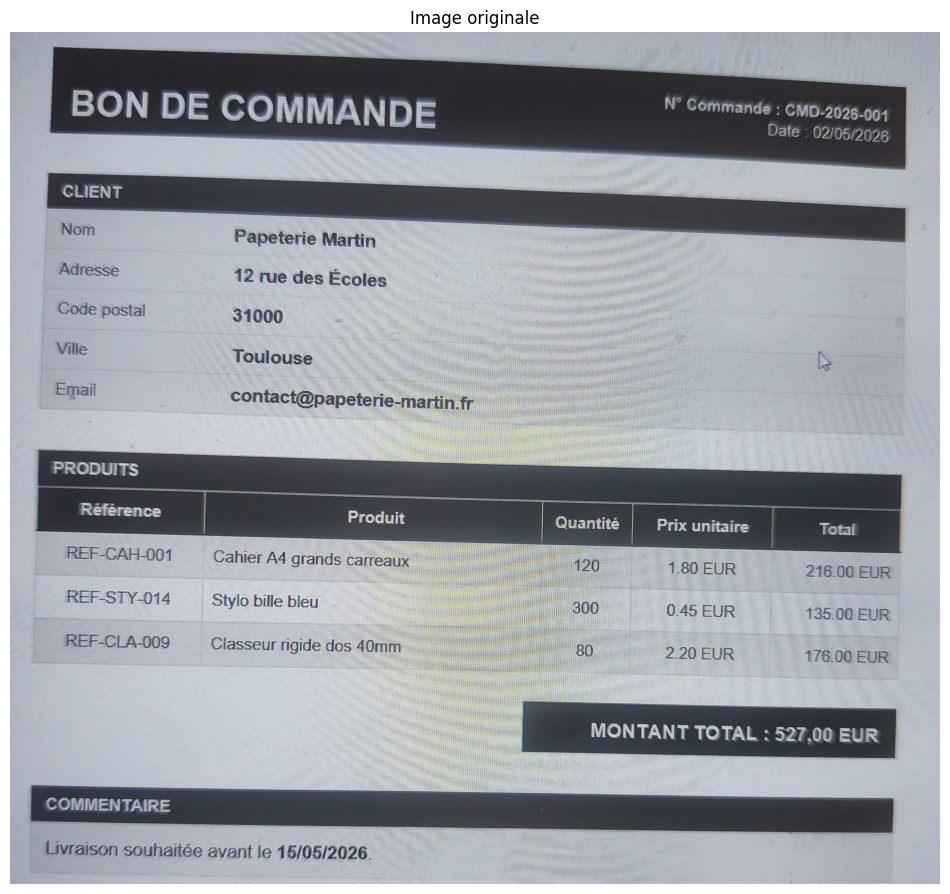

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Ouverture de l'image
image = Image.open(image_path)

# Affichage de l'image
plt.figure(figsize=(12, 16))
plt.imshow(image)
plt.axis("off")
plt.title("Image originale")
plt.show()

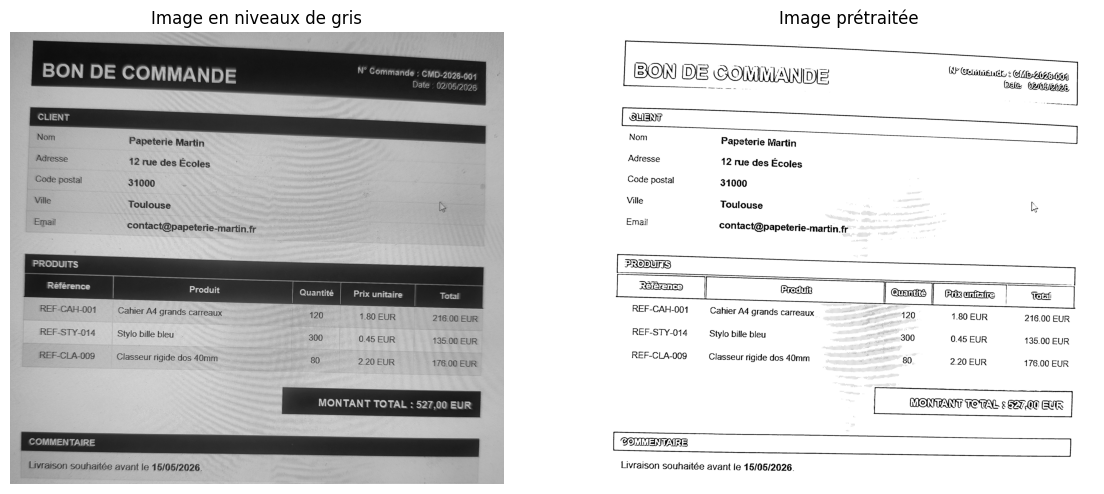

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Lecture de l'image avec OpenCV
img = cv2.imread(image_path)

# Conversion en niveaux de gris
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Agrandissement de l'image pour aider l'OCR
scale_percent = 150
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)
gray_resized = cv2.resize(gray, (width, height), interpolation=cv2.INTER_CUBIC)

# Réduction légère du bruit
denoised = cv2.fastNlMeansDenoising(gray_resized, None, 30, 7, 21)

# Amélioration du contraste
contrast = cv2.convertScaleAbs(denoised, alpha=1.5, beta=0)

# Seuillage adaptatif pour rendre le texte plus lisible
processed = cv2.adaptiveThreshold(
    contrast,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    15
)

# Affichage avant / après
plt.figure(figsize=(14, 10))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Image en niveaux de gris")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed, cmap="gray")
plt.title("Image prétraitée")
plt.axis("off")

plt.show()

In [ ]:
import pytesseract

# Configuration OCR
custom_config = r'--oem 3 --psm 6'

# OCR sur l'image prétraitée
texte_ocr = pytesseract.image_to_string(
    processed,
    lang='fra+eng',
    config=custom_config
)

print("===== TEXTE OCR EXTRAIT =====")
print(texte_ocr)

===== TEXTE OCR EXTRAIT =====
(ere. U crcr.
Nom Papeterie Martin
Adresse 12 rue des Écoles
Code postal 31000
Ville Toulouse un | Ls
Email contact@papeterie-martin fr "
PRODUIES| —
=a
REF-CAH-001 Cahier A4 grands carreaux _ i120 1.80 EUR 216.00 EUR
REF-STY-014 Stylo bille bleu “200 0.45 EUR 135.00 EUR
A ne
REF-CLA-009 Classeur rigide dos 40mm ‘6 2.20 EUR 176.00 EUR
aaa LT
| _ _ = _—
Livraison souhaitée avant le 15/05/2026.



In [ ]:
import re
import pandas as pd

# Nettoyage léger du texte OCR
texte = texte_ocr.replace("\n\n", "\n")
texte = texte.replace(",", ".")
texte = texte.replace("€", "EUR")

print("===== TEXTE NETTOYÉ =====")
print(texte)

# Extraction des infos client
def extract_field(pattern, text, default=""):
    match = re.search(pattern, text, re.IGNORECASE)
    return match.group(1).strip() if match else default

client_nom = extract_field(r"Nom\s+(.+)", texte)
adresse = extract_field(r"Adresse\s+(.+)", texte)
code_postal = extract_field(r"Code postal\s+(\d{5})", texte)
ville = extract_field(r"Ville\s+([A-Za-zÀ-ÿ\- ]+)", texte)
email = extract_field(r"Email\s+([^\n]+)", texte)

# Correction simple email OCR
email = email.replace(" ", ".") if "@" in email and ".fr" not in email else email
email = email.replace("..", ".")

# Extraction des lignes produits
lignes = texte.split("\n")
produits = []

for ligne in lignes:
    if "REF-" in ligne:
        # Nettoyage des caractères parasites
        ligne_clean = ligne.replace("_", " ")
        ligne_clean = ligne_clean.replace("“", "")
        ligne_clean = ligne_clean.replace("‘", "")
        ligne_clean = ligne_clean.replace("'", "")
        ligne_clean = re.sub(r"\s+", " ", ligne_clean).strip()

        # Pattern : REF + produit + quantité approximative + prix + total
        match = re.search(
            r"(REF-[A-Z]+-\d+)\s+(.+?)\s+([A-Za-z]*\d+)\s+(\d+\.\d{2})\s+EUR\s+(\d+\.\d{2})\s+EUR",
            ligne_clean
        )

        if match:
            reference = match.group(1)
            produit = match.group(2).strip()
            quantite_ocr = match.group(3)
            prix_unitaire = float(match.group(4))
            total_ligne = float(match.group(5))

            # Correction automatique de la quantité via total / prix unitaire
            quantite_calculee = round(total_ligne / prix_unitaire)

            produits.append({
                "Client": client_nom,
                "Adresse": adresse,
                "Code postal": code_postal,
                "Ville": ville,
                "Email": email,
                "Référence": reference,
                "Produit": produit,
                "Quantité OCR": quantite_ocr,
                "Quantité corrigée": quantite_calculee,
                "Prix unitaire": prix_unitaire,
                "Total ligne": total_ligne
            })

df = pd.DataFrame(produits)

df

===== TEXTE NETTOYÉ =====
(ere. U crcr.
Nom Papeterie Martin
Adresse 12 rue des Écoles
Code postal 31000
Ville Toulouse un | Ls
Email contact@papeterie-martin fr "
PRODUIES| —
=a
REF-CAH-001 Cahier A4 grands carreaux _ i120 1.80 EUR 216.00 EUR
REF-STY-014 Stylo bille bleu “200 0.45 EUR 135.00 EUR
A ne
REF-CLA-009 Classeur rigide dos 40mm ‘6 2.20 EUR 176.00 EUR
aaa LT
| _ _ = _—
Livraison souhaitée avant le 15/05/2026.



,Client,Adresse,Code postal,Ville,Email,Référence,Produit,Quantité OCR,Quantité corrigée,Prix unitaire,Total ligne
0,Papeterie Martin,12 rue des Écoles,31000,Toulouse un,"contact@papeterie-martin.fr.""",REF-CAH-001,Cahier A4 grands carreaux,i120,120,1.80,216.0
1,Papeterie Martin,12 rue des Écoles,31000,Toulouse un,"contact@papeterie-martin.fr.""",REF-STY-014,Stylo bille bleu,200,300,0.45,135.0
2,Papeterie Martin,12 rue des Écoles,31000,Toulouse un,"contact@papeterie-martin.fr.""",REF-CLA-009,Classeur rigide dos 40mm,6,80,2.20,176.0


In [ ]:
# Copie du tableau pour nettoyage final
df_clean = df.copy()

# Nettoyage ville
df_clean["Ville"] = df_clean["Ville"].str.replace(" un", "", regex=False).str.strip()

# Nettoyage email
df_clean["Email"] = (
    df_clean["Email"]
    .str.replace('"', '', regex=False)
    .str.replace(" ", ".", regex=False)
    .str.replace("..", ".", regex=False)
    .str.strip()
)

# Nettoyage quantité OCR : garder uniquement les chiffres
df_clean["Quantité OCR"] = df_clean["Quantité OCR"].astype(str).str.extract(r"(\d+)")[0]

# Ajouter un statut de validation
df_clean["Statut validation"] = df_clean.apply(
    lambda row: "À vérifier" if str(row["Quantité OCR"]) != str(row["Quantité corrigée"]) else "OK",
    axis=1
)

# Réorganisation des colonnes
df_clean = df_clean[
    [
        "Client",
        "Adresse",
        "Code postal",
        "Ville",
        "Email",
        "Référence",
        "Produit",
        "Quantité OCR",
        "Quantité corrigée",
        "Prix unitaire",
        "Total ligne",
        "Statut validation"
    ]
]

df_clean

,Client,Adresse,Code postal,Ville,Email,Référence,Produit,Quantité OCR,Quantité corrigée,Prix unitaire,Total ligne,Statut validation
0,Papeterie Martin,12 rue des Écoles,31000,Toulouse,contact@papeterie-martin.fr.,REF-CAH-001,Cahier A4 grands carreaux,120,120,1.80,216.0,OK
1,Papeterie Martin,12 rue des Écoles,31000,Toulouse,contact@papeterie-martin.fr.,REF-STY-014,Stylo bille bleu,200,300,0.45,135.0,À vérifier
2,Papeterie Martin,12 rue des Écoles,31000,Toulouse,contact@papeterie-martin.fr.,REF-CLA-009,Classeur rigide dos 40mm,6,80,2.20,176.0,À vérifier


In [ ]:
# Export du tableau final en CSV
csv_path = "resultat_ocr_bon_commande.csv"

df_clean.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"Fichier CSV généré : {csv_path}")

Fichier CSV généré : resultat_ocr_bon_commande.csv


In [ ]:
from google.colab import files

files.download(csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>